<a href="https://colab.research.google.com/github/jrose0215/schoolwork/blob/main/capstone-mtg-price-analysis/panopto_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Loading all the tools I need to continue first
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import numpy as np

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# Scryfall updates their download link daily so I can't hardcode it.
# This first request asks Scryfall where today's file is located.
bulk_info_url = "https://api.scryfall.com/bulk-data"
response = requests.get(bulk_info_url)
bulk_data = response.json()

# From the response, I'm grabbing just the "default_cards" file.
# This is the one that has one entry per card printing with price data.
default_cards_entry = next(
    item for item in bulk_data["data"] if item["type"] == "default_cards"
)

# Pulling out just the actual download URL from that entry.
download_url = default_cards_entry["download_uri"]
print(f"Download URL found: {download_url}")

# Now downloading the full card dataset — this can take about 30-60 seconds.
# Roughly 200-300MB of data.
print("Downloading card data...")
cards_response = requests.get(download_url)

# Converting the raw downloaded data into a Python list I can work with.
# Each item in the list is one card with all its details.
cards_data = cards_response.json()

# Counts how many items are in the list or how many cards we got.
print(f"Total cards downloaded: {len(cards_data):,}")

Download URL found: https://data.scryfall.io/default-cards/default-cards-20260402090808.json
Total cards downloaded: 113,185


In [ ]:
# Loading the card list into a DataFrame — rows = cards, columns = attributes
df_raw = pd.DataFrame(cards_data)

# Verifying what we have
print(f"Shape: {df_raw.shape}")  # rows x columns
print(f"\nSample cmc values:\n{df_raw['cmc'].head(10)}")
print(f"\nSample prices values:\n{df_raw['prices'].head(3)}")

Shape: (113185, 88)

Sample cmc values:
0    0.0
1    6.0
2    2.0
3    0.0
4    3.0
5    1.0
6    0.0
7    2.0
8    5.0
9    1.0
Name: cmc, dtype: float64

Sample prices values:
0    {'usd': '0.36', 'usd_foil': '0.45', 'usd_etche...
1    {'usd': '0.56', 'usd_foil': '2.92', 'usd_etche...
2    {'usd': '0.18', 'usd_foil': '1.77', 'usd_etche...
Name: prices, dtype: object


In [ ]:
# Pulls the 'usd' price out of the nested prices dictionary into its own column
df_raw["price_usd"] = df_raw["prices"].apply(
    lambda x: float(x["usd"]) if x.get("usd") is not None else None
)

# Keep only the columns we actually need
df = df_raw[["name", "cmc", "price_usd", "rarity", "lang"]].copy()

print(f"Before filtering: {len(df):,} rows")

# English cards only
df = df[df["lang"] == "en"]
print(f"After English filter: {len(df):,} rows")

# Drops rows missing cmc or price
df = df.dropna(subset=["cmc", "price_usd"])
print(f"After dropping nulls: {len(df):,} rows")

# Remove cards with $0 price
df = df[df["price_usd"] > 0]
print(f"After removing $0 prices: {len(df):,} rows")

# Cap cmc at 17
df = df[df["cmc"] <= 17]
print(f"After capping cmc at 17: {len(df):,} rows")

# Show stats
print(f"\nBasic statistics:\n{df[['cmc', 'price_usd']].describe()}")

Before filtering: 113,185 rows
After English filter: 110,676 rows
After dropping nulls: 81,559 rows
After removing $0 prices: 81,559 rows
After capping cmc at 17: 81,558 rows

Basic statistics:
                cmc     price_usd
count  81558.000000  81558.000000
mean       2.919389      4.686892
std        1.966274     53.055738
min        0.000000      0.010000
25%        2.000000      0.150000
50%        3.000000      0.310000
75%        4.000000      1.280000
max       16.000000   5142.020000


In [ ]:
r, p_value = stats.pearsonr(df["cmc"], df["price_usd"])

alpha = 0.05

print("=" * 50)
print("PEARSON CORRELATION RESULTS")
print("=" * 50)
print(f"Pearson r:    {r:.4f}")
print(f"P-value:      {p_value:.4e}")
print(f"Alpha:        {alpha}")
print(f"Sample size:  {len(df):,}")
print()

if p_value < alpha:
    print("CONCLUSION: Reject the null hypothesis.")
    print("There IS a statistically significant correlation")
    print("between cmc and USD market price.")
else:
    print("CONCLUSION: Fail to reject the null hypothesis.")
    print("There is NO statistically significant correlation")
    print("between cmc and USD market price.")

PEARSON CORRELATION RESULTS
Pearson r:    -0.0252
P-value:      5.6698e-13
Alpha:        0.05
Sample size:  81,558

CONCLUSION: Reject the null hypothesis.
There IS a statistically significant correlation
between cmc and USD market price.


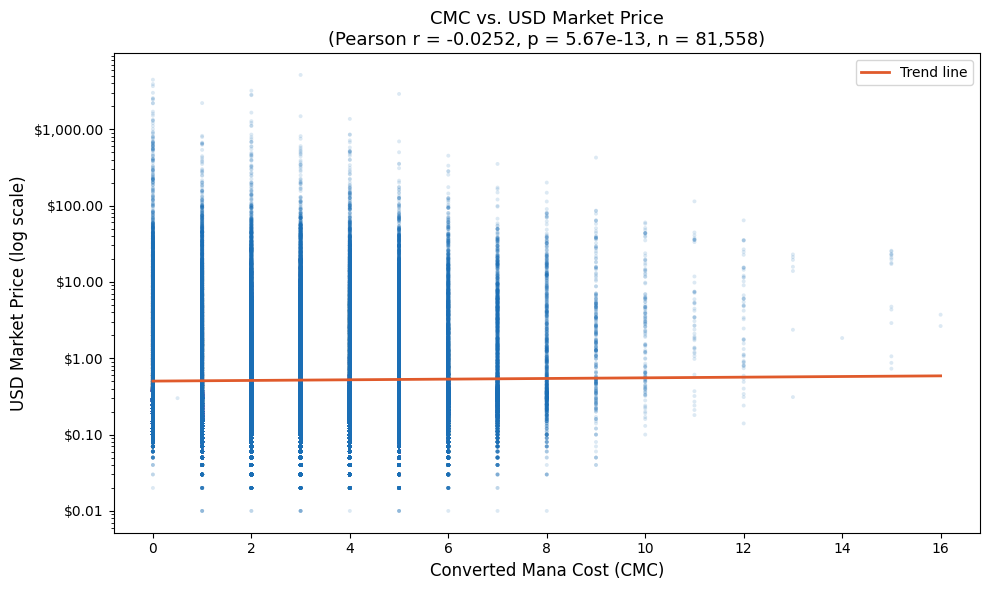

Scatter plot saved.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting each card as a dot
# Overlapping dots so they don't just look like a solid blob
ax.scatter(
    df["cmc"],
    df["price_usd"],
    alpha=0.15,
    s=8,
    color="#1a6eb5",
    edgecolors="none"
)

# Fit and draw a trend line
m, b = np.polyfit(df["cmc"], np.log10(df["price_usd"] + 0.01), 1)
x_line = np.linspace(df["cmc"].min(), df["cmc"].max(), 200)
y_line = 10 ** (m * x_line + b)
ax.plot(x_line, y_line, color="#e05a2b", linewidth=2, label="Trend line")

# Log scale because prices span from $0.01 to $5,000+
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.2f}"))
ax.set_xlabel("Converted Mana Cost (CMC)", fontsize=12)
ax.set_ylabel("USD Market Price (log scale)", fontsize=12)
ax.set_title(
    f"CMC vs. USD Market Price\n(Pearson r = {r:.4f}, p = {p_value:.2e}, n = {len(df):,})",
    fontsize=13
)
ax.legend()
plt.tight_layout()
plt.savefig("scatter_cmc_vs_price.png", dpi=150)
plt.show()
print("Scatter plot saved.")

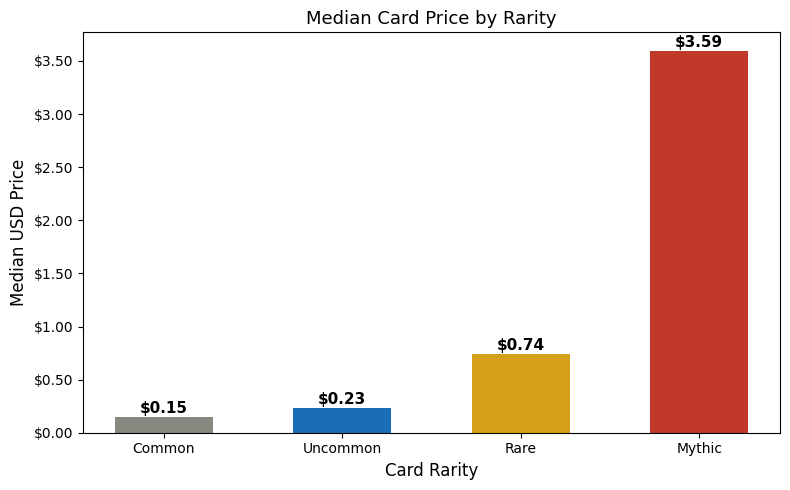

Bar chart saved.


In [ ]:
rarity_order = ["common", "uncommon", "rare", "mythic"]
rarity_labels = ["Common", "Uncommon", "Rare", "Mythic"]
rarity_colors = ["#888780", "#1a6eb5", "#d4a017", "#c0392b"]

# Calculate median price and card count for each rarity
avg_price_by_rarity = (
    df[df["rarity"].isin(rarity_order)]
    .groupby("rarity")["price_usd"]
    .median()
    .reindex(rarity_order)
)

count_by_rarity = (
    df[df["rarity"].isin(rarity_order)]
    .groupby("rarity")["price_usd"]
    .count()
    .reindex(rarity_order)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    rarity_labels,
    avg_price_by_rarity.values,
    color=rarity_colors,
    edgecolor="none",
    width=0.55
)

# Add the dollar value label on top of each bar
for bar, val in zip(bars, avg_price_by_rarity.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"${val:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_xlabel("Card Rarity", fontsize=12)
ax.set_ylabel("Median USD Price", fontsize=12)
ax.set_title("Median Card Price by Rarity", fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.2f}"))
plt.tight_layout()
plt.savefig("bar_price_by_rarity.png", dpi=150)
plt.show()
print("Bar chart saved.")

In [ ]:
# Results from different calculations and visuals
print("=" * 55)
print("Summary of Statistical Analysis")
print("=" * 55)
print(f"Dataset size (after cleaning):  {len(df):,} cards")
print(f"Pearson r:                       {r:.4f}")
print(f"P-value:                         {p_value:.4e}")
print(f"Alpha:                           {alpha}")
print(f"Statistically significant:       {'Yes' if p_value < alpha else 'No'}")
print()
print("Median price by rarity:")
for rarity, label in zip(rarity_order, rarity_labels):
    if rarity in avg_price_by_rarity.index:
        n = count_by_rarity[rarity]
        med = avg_price_by_rarity[rarity]
        print(f"  {label:<12} ${med:.2f}  (n={n:,})")
print()

if abs(r) < 0.1:
    strength = "negligible"
elif abs(r) < 0.3:
    strength = "weak"
elif abs(r) < 0.5:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if r > 0 else "negative"
print(f"Correlation strength: {strength} and {direction} (r = {r:.4f})")
print(f"CMC explains approximately {r**2 * 100:.2f}% of variance in price.")

Summary of Statistical Analysis
Dataset size (after cleaning):  81,558 cards
Pearson r:                       -0.0252
P-value:                         5.6698e-13
Alpha:                           0.05
Statistically significant:       Yes

Median price by rarity:
  Common       $0.15  (n=26,728)
  Uncommon     $0.23  (n=21,202)
  Rare         $0.74  (n=27,603)
  Mythic       $3.59  (n=5,776)

Correlation strength: negligible and negative (r = -0.0252)
CMC explains approximately 0.06% of variance in price.
